In [1]:
!pip install captum --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.8 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from captum.attr import IntegratedGradients, NoiseTunnel

print('PyTorch:', torch.__version__)

PyTorch: 2.10.0+cpu


In [3]:
MODEL_PATH   = 'dl_fog_model_best.pth'
ZIP_PATH     = 'tdcsfog.zip'
EXTRACT_PATH = 'tdcsfog_csvs'

FS              = 128
WINDOW_SIZE     = 192
STEP            = 128
FOG_THRESH_HIGH = 0.6
FOG_THRESH_LOW  = 0.4
BATCH_SIZE      = 64
AXES            = ['AccV', 'AccML', 'AccAP']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [4]:
class FoGModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool1d(2)
        self.drop  = nn.Dropout(0.3)
        self.lstm  = nn.LSTM(
            input_size=64, hidden_size=64,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)                  # (B, 3, 192)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)                         # (B, 32, 96)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)                         # (B, 64, 48)
        x = self.drop(x)
        x = x.permute(0, 2, 1)                  # (B, 48, 64)
        x, _ = self.lstm(x)                      # (B, 48, 128)
        x = x.mean(dim=1)                        # (B, 128)
        return self.fc(x)                        # (B, 1)


model = FoGModel().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Model loaded and ready')

Model loaded and ready


In [5]:
if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_PATH)
    print('Extracted zip')

csv_files = [
    os.path.join(EXTRACT_PATH, f)
    for f in os.listdir(EXTRACT_PATH)
    if f.endswith('.csv')
]
print(f'Found {len(csv_files)} CSV files')


def extract_windows(df):
    df = df.copy()
    df['FOG'] = (
        (df['StartHesitation'] == 1) |
        (df['Turn']            == 1) |
        (df['Walking']         == 1)
    ).astype(int)
    signals    = df[AXES].values.astype(np.float32)
    fog_labels = df['FOG'].values
    T          = len(df)
    X, y, t_starts, t_ends = [], [], [], []
    for start in range(0, T - WINDOW_SIZE, STEP):
        end       = start + WINDOW_SIZE
        fog_ratio = fog_labels[start:end].mean()
        if fog_ratio >= FOG_THRESH_HIGH:
            label = 1
        elif fog_ratio <= FOG_THRESH_LOW:
            label = 0
        else:
            continue
        X.append(signals[start:end])
        y.append(label)
        t_starts.append(start / FS)
        t_ends.append(end   / FS)
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int8),
            np.array(t_starts, dtype=np.float32),
            np.array(t_ends,   dtype=np.float32))


from tqdm import tqdm

X_list, y_list, subj_list = [], [], []

for path in tqdm(csv_files, desc='Loading windows'):
    df = pd.read_csv(path)
    required = {'AccV','AccML','AccAP','StartHesitation','Turn','Walking'}
    if not required.issubset(df.columns):
        continue
    X, y, _, _ = extract_windows(df)
    if len(y) == 0:
        continue
    subj_id = os.path.basename(path).replace('.csv', '')
    X_list.append(X)
    y_list.append(y)
    subj_list.extend([subj_id] * len(y))

X_all       = np.concatenate(X_list, axis=0)
y_all       = np.concatenate(y_list, axis=0)
subject_ids = np.array(subj_list)

unique_subjects = np.unique(subject_ids)
train_subj, temp_subj = train_test_split(unique_subjects, test_size=0.30, random_state=42)
val_subj,   test_subj = train_test_split(temp_subj,       test_size=0.50, random_state=42)

test_mask = np.isin(subject_ids, test_subj)
X_test    = X_all[test_mask]
y_test    = y_all[test_mask]

print(f'Test windows : {len(y_test)}')
print(f'FOG windows  : {(y_test==1).sum()}')
print(f'Non-FOG      : {(y_test==0).sum()}')

Extracted zip
Found 833 CSV files


Loading windows: 100%|██████████| 833/833 [00:10<00:00, 81.33it/s]


Test windows : 9413
FOG windows  : 4155
Non-FOG      : 5258


In [6]:
def normalise(x_np):
    """Per-window z-score — same as training.
    x_np : (N, 192, 3)  numpy float32
    returns: (N, 192, 3) normalised tensor
    """
    t   = torch.tensor(x_np, dtype=torch.float32)
    mu  = t.mean(dim=1, keepdim=True)   # (N, 1, 3)
    std = t.std(dim=1,  keepdim=True) + 1e-8
    return (t - mu) / std


X_test_norm = normalise(X_test)   # (N, 192, 3)  — keep on CPU until needed

all_probs, all_preds = [], []

model.eval()
with torch.no_grad():
    for i in range(0, len(X_test_norm), BATCH_SIZE):
        batch  = X_test_norm[i:i+BATCH_SIZE].to(device)
        probs  = torch.sigmoid(model(batch)).cpu().numpy().flatten()
        preds  = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

acc = (all_preds == y_test).mean()
print(f'Test accuracy on this run: {acc:.4f}')
print('(should match ~0.92 from training notebook)')

Test accuracy on this run: 0.9131
(should match ~0.92 from training notebook)


In [7]:
ig = IntegratedGradients(model)


def get_attributions(x_norm_tensor, n_steps=50):
    """
    Compute Integrated Gradients for a batch of normalised windows.

    x_norm_tensor : (N, 192, 3)  float32 tensor  (normalised, on CPU)
    n_steps       : more steps = more accurate, but slower

    Returns: (N, 192, 3) numpy array of attribution scores
    """
    x = x_norm_tensor.to(device)
    x.requires_grad_(True)

    # Baseline = all-zeros (silence = no signal = neutral reference)
    baseline = torch.zeros_like(x)

    attrs = ig.attribute(
        x,
        baselines=baseline,
        target=0,          # output neuron 0 (only 1 output in FoGModel)
        n_steps=n_steps,
        return_convergence_delta=False
    )
    return attrs.detach().cpu().numpy()   # (N, 192, 3)


print('Integrated Gradients function ready')

Integrated Gradients function ready


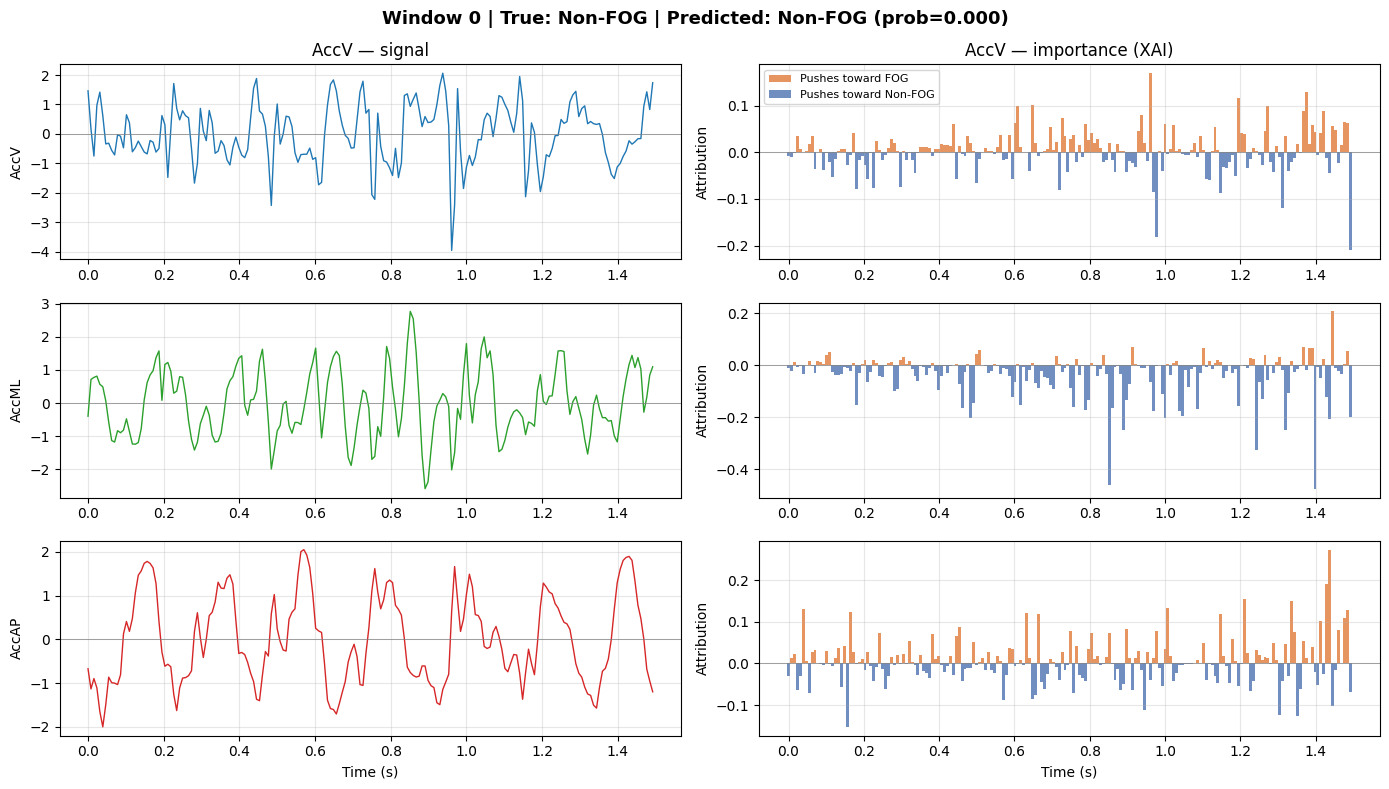

Saved: xai_single_window.png

HOW TO READ THIS:
  Orange bars = these time samples PUSHED the model toward predicting FOG
  Blue bars   = these time samples PUSHED the model toward Non-FOG
  Tall orange bars = the model is confident because of THAT moment in the signal


In [9]:
# ── CHANGE THIS to look at any window you want ──
WINDOW_IDX = 0    # 0 = first test window; try different numbers
# ────────────────────────────────────────────────

x_single = X_test_norm[WINDOW_IDX:WINDOW_IDX+1]   # (1, 192, 3)
attrs     = get_attributions(x_single)              # (1, 192, 3)

signal = x_single[0].detach().numpy()     # (192, 3)  normalised signal
attr   = attrs[0]                 # (192, 3)  attribution scores

true_label = 'FOG' if y_test[WINDOW_IDX] == 1 else 'Non-FOG'
pred_label = 'FOG' if all_preds[WINDOW_IDX] == 1 else 'Non-FOG'
prob       = all_probs[WINDOW_IDX]

time_axis = np.arange(WINDOW_SIZE) / FS   # seconds

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle(
    f'Window {WINDOW_IDX} | True: {true_label} | Predicted: {pred_label} (prob={prob:.3f})',
    fontsize=13, fontweight='bold'
)

colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, axis_name in enumerate(AXES):
    ax_sig  = axes[i][0]
    ax_attr = axes[i][1]

    # Left column: raw (normalised) signal
    ax_sig.plot(time_axis, signal[:, i], color=colors[i], linewidth=1)
    ax_sig.set_ylabel(axis_name, fontsize=10)
    ax_sig.set_xlabel('Time (s)' if i == 2 else '')
    ax_sig.set_title(f'{axis_name} — signal' if i == 0 else '')
    ax_sig.grid(True, alpha=0.3)
    ax_sig.axhline(0, color='gray', linewidth=0.5)

    # Right column: attribution heatmap bars
    a = attr[:, i]
    # Positive attributions (push toward FOG) in orange; negative in blue
    ax_attr.bar(time_axis, np.where(a > 0, a, 0),
                width=1/FS, color='#e07b39', alpha=0.8, label='Pushes toward FOG')
    ax_attr.bar(time_axis, np.where(a < 0, a, 0),
                width=1/FS, color='#4c72b0', alpha=0.8, label='Pushes toward Non-FOG')
    ax_attr.axhline(0, color='gray', linewidth=0.5)
    ax_attr.set_ylabel('Attribution', fontsize=10)
    ax_attr.set_xlabel('Time (s)' if i == 2 else '')
    ax_attr.set_title(f'{axis_name} — importance (XAI)' if i == 0 else '')
    ax_attr.grid(True, alpha=0.3)
    if i == 0:
        ax_attr.legend(fontsize=8)

plt.tight_layout()
plt.savefig('xai_single_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xai_single_window.png')
print()
print('HOW TO READ THIS:')
print('  Orange bars = these time samples PUSHED the model toward predicting FOG')
print('  Blue bars   = these time samples PUSHED the model toward Non-FOG')
print('  Tall orange bars = the model is confident because of THAT moment in the signal')

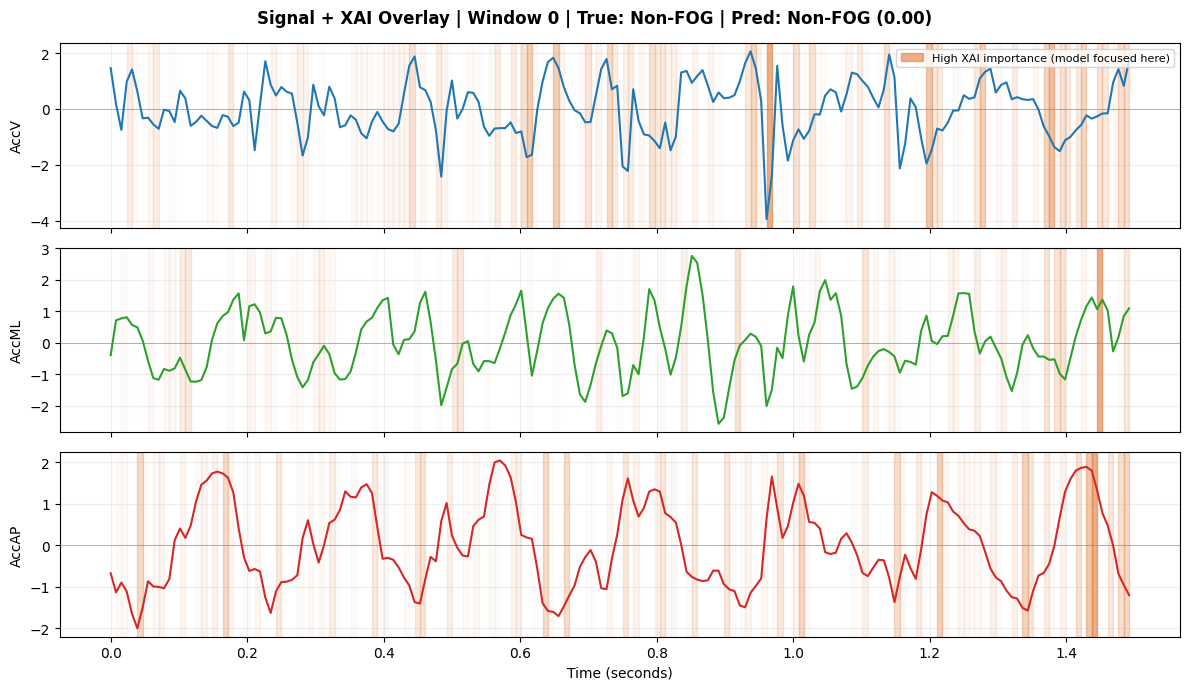

Saved: xai_overlay.png

HOW TO READ THIS:
  Dark orange shading = the model paid heavy attention to this moment
  No shading = the model mostly ignored this moment


In [11]:
# ── CHANGE THIS to any FOG window index ──
WINDOW_IDX = 0
# ─────────────────────────────────────────

x_single = X_test_norm[WINDOW_IDX:WINDOW_IDX+1]
attrs     = get_attributions(x_single)
signal    = x_single[0].detach().numpy()
attr      = attrs[0]

true_label = 'FOG' if y_test[WINDOW_IDX] == 1 else 'Non-FOG'
pred_label = 'FOG' if all_preds[WINDOW_IDX] == 1 else 'Non-FOG'
prob       = all_probs[WINDOW_IDX]
time_axis  = np.arange(WINDOW_SIZE) / FS

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle(
    f'Signal + XAI Overlay | Window {WINDOW_IDX} | True: {true_label} | Pred: {pred_label} ({prob:.2f})',
    fontsize=12, fontweight='bold'
)

axis_colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, (axis_name, col) in enumerate(zip(AXES, axis_colors)):
    ax = axes[i]
    sig_vals  = signal[:, i]
    attr_vals = attr[:, i]

    # Normalise attribution to [0, 1] for alpha shading
    a_pos   = np.clip(attr_vals, 0, None)
    a_max   = a_pos.max() + 1e-9
    a_norm  = a_pos / a_max

    # Plot signal
    ax.plot(time_axis, sig_vals, color=col, linewidth=1.5, label=axis_name, zorder=3)

    # Shade the background by attribution strength
    for t in range(len(time_axis) - 1):
        ax.axvspan(
            time_axis[t], time_axis[t+1],
            alpha=float(a_norm[t]) * 0.6,
            color='#e07b39', zorder=1
        )

    ax.set_ylabel(axis_name, fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='gray', linewidth=0.4)

    # Add a colorbar-style legend only on first axis
    if i == 0:
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(color='#e07b39', alpha=0.6, label='High XAI importance (model focused here)')],
            fontsize=8, loc='upper right'
        )

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.savefig('xai_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xai_overlay.png')
print()
print('HOW TO READ THIS:')
print('  Dark orange shading = the model paid heavy attention to this moment')
print('  No shading = the model mostly ignored this moment')

In [12]:
# ── How many FOG windows to analyse (more = slower but more reliable) ──
N_SAMPLES = 100
# ───────────────────────────────────────────────────────────────────────

# Grab correctly-predicted FOG windows
correct_fog_idx = np.where((y_test == 1) & (all_preds == 1))[0]
chosen_idx      = correct_fog_idx[:N_SAMPLES]

print(f'Computing attributions for {len(chosen_idx)} correctly-predicted FOG windows...')
print('(this takes ~1-2 minutes on CPU)')

all_attrs = []

# Process in small batches to avoid memory issues
ATTR_BATCH = 10
for start in range(0, len(chosen_idx), ATTR_BATCH):
    batch_idx = chosen_idx[start:start+ATTR_BATCH]
    x_batch   = X_test_norm[batch_idx]           # (B, 192, 3)
    attrs     = get_attributions(x_batch, n_steps=30)
    all_attrs.append(np.abs(attrs))              # take absolute value = total importance
    if start % 50 == 0:
        print(f'  Done {start}/{len(chosen_idx)}')

all_attrs_arr = np.concatenate(all_attrs, axis=0)  # (N, 192, 3)
mean_attr     = all_attrs_arr.mean(axis=0)          # (192, 3)  — average over windows

print('Done!')
print(f'Mean attribution shape: {mean_attr.shape}')

Computing attributions for 100 correctly-predicted FOG windows...
(this takes ~1-2 minutes on CPU)
  Done 0/100
  Done 50/100
Done!
Mean attribution shape: (192, 3)


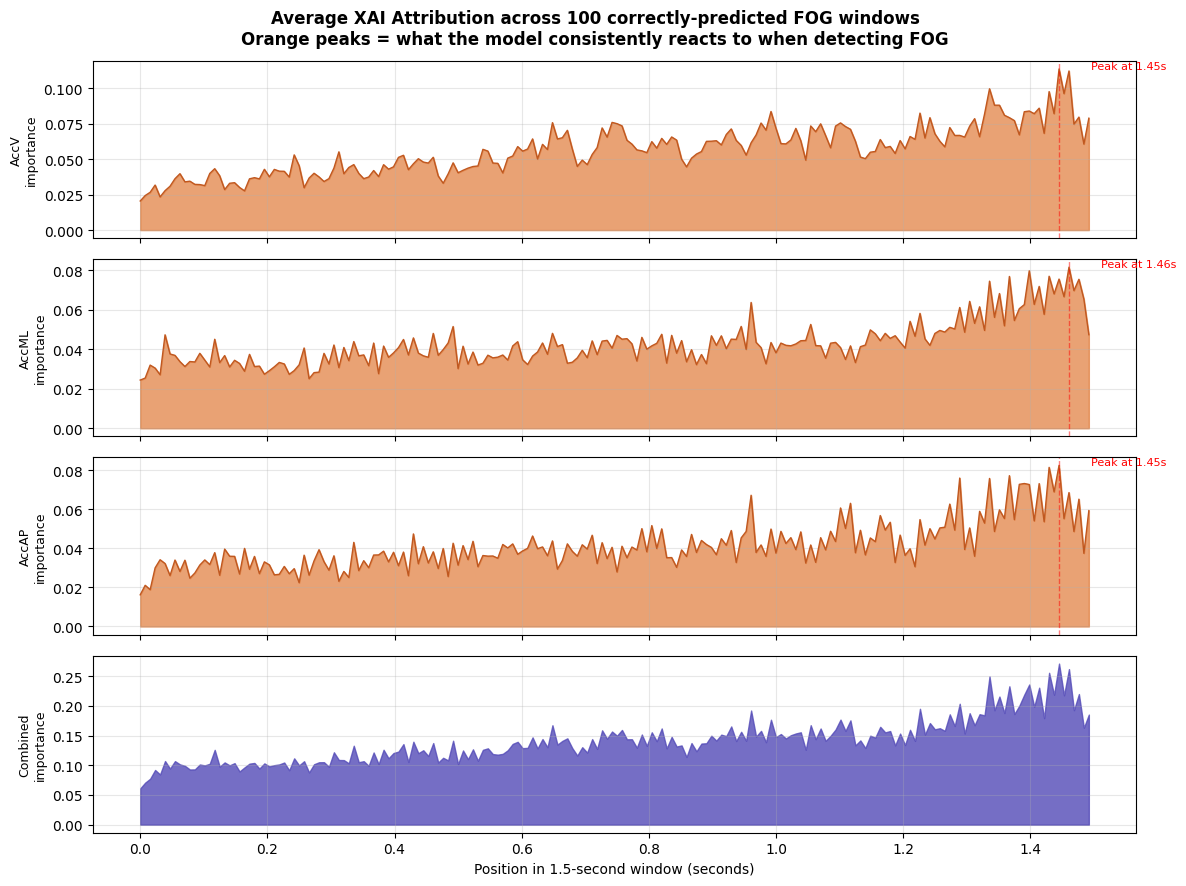

Saved: xai_average_fog.png

HOW TO READ THIS:
  A peak at t=0.0s means the model reacts to the START of the FOG window
  A peak at t=0.75s means it reacts to the MIDDLE — perhaps a tremor pattern
  A peak at t=1.5s means it reacts to the END — perhaps a freeze onset
  The axis with the tallest peak = the most informative sensor direction


In [13]:
time_axis = np.arange(WINDOW_SIZE) / FS

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    f'Average XAI Attribution across {len(chosen_idx)} correctly-predicted FOG windows\n'
    'Orange peaks = what the model consistently reacts to when detecting FOG',
    fontsize=12, fontweight='bold'
)

axis_colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, (axis_name, col) in enumerate(zip(AXES, axis_colors)):
    ax = axes[i]
    a  = mean_attr[:, i]
    ax.fill_between(time_axis, a, alpha=0.7, color='#e07b39')
    ax.plot(time_axis, a, color='#c05820', linewidth=1)
    ax.set_ylabel(f'{axis_name}\nimportance', fontsize=9)
    ax.grid(True, alpha=0.3)
    peak_t = time_axis[np.argmax(a)]
    ax.axvline(peak_t, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.annotate(f'Peak at {peak_t:.2f}s', xy=(peak_t, a.max()),
                xytext=(peak_t + 0.05, a.max()),
                fontsize=8, color='red')

# Bottom panel: combined importance (sum across all 3 axes)
combined = mean_attr.sum(axis=1)
axes[3].fill_between(time_axis, combined, alpha=0.8, color='#534AB7')
axes[3].set_ylabel('Combined\nimportance', fontsize=9)
axes[3].set_xlabel('Position in 1.5-second window (seconds)', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xai_average_fog.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xai_average_fog.png')
print()
print('HOW TO READ THIS:')
print('  A peak at t=0.0s means the model reacts to the START of the FOG window')
print('  A peak at t=0.75s means it reacts to the MIDDLE — perhaps a tremor pattern')
print('  A peak at t=1.5s means it reacts to the END — perhaps a freeze onset')
print('  The axis with the tallest peak = the most informative sensor direction')

In [14]:
N_COMPARE = 50   # windows per group

# Group 1: True FOG, correctly predicted as FOG (true positives)
tp_idx = np.where((y_test == 1) & (all_preds == 1))[0][:N_COMPARE]

# Group 2: True FOG, wrongly predicted as Non-FOG (false negatives — model missed them)
fn_idx = np.where((y_test == 1) & (all_preds == 0))[0][:N_COMPARE]

print(f'True Positives available : {len(np.where((y_test==1)&(all_preds==1))[0])}')
print(f'False Negatives available: {len(np.where((y_test==1)&(all_preds==0))[0])}')

def avg_attr(idx_list, n_steps=30):
    """Average absolute attributions for a list of window indices."""
    attrs_list = []
    for start in range(0, len(idx_list), ATTR_BATCH):
        batch = idx_list[start:start+ATTR_BATCH]
        a     = get_attributions(X_test_norm[batch], n_steps=n_steps)
        attrs_list.append(np.abs(a))
    return np.concatenate(attrs_list, axis=0).mean(axis=0)  # (192, 3)

print('Computing attributions for true positives...')
tp_attr = avg_attr(tp_idx)
print('Computing attributions for false negatives...')
fn_attr = avg_attr(fn_idx) if len(fn_idx) > 0 else None
print('Done!')

True Positives available : 3639
False Negatives available: 516
Computing attributions for true positives...
Computing attributions for false negatives...
Done!


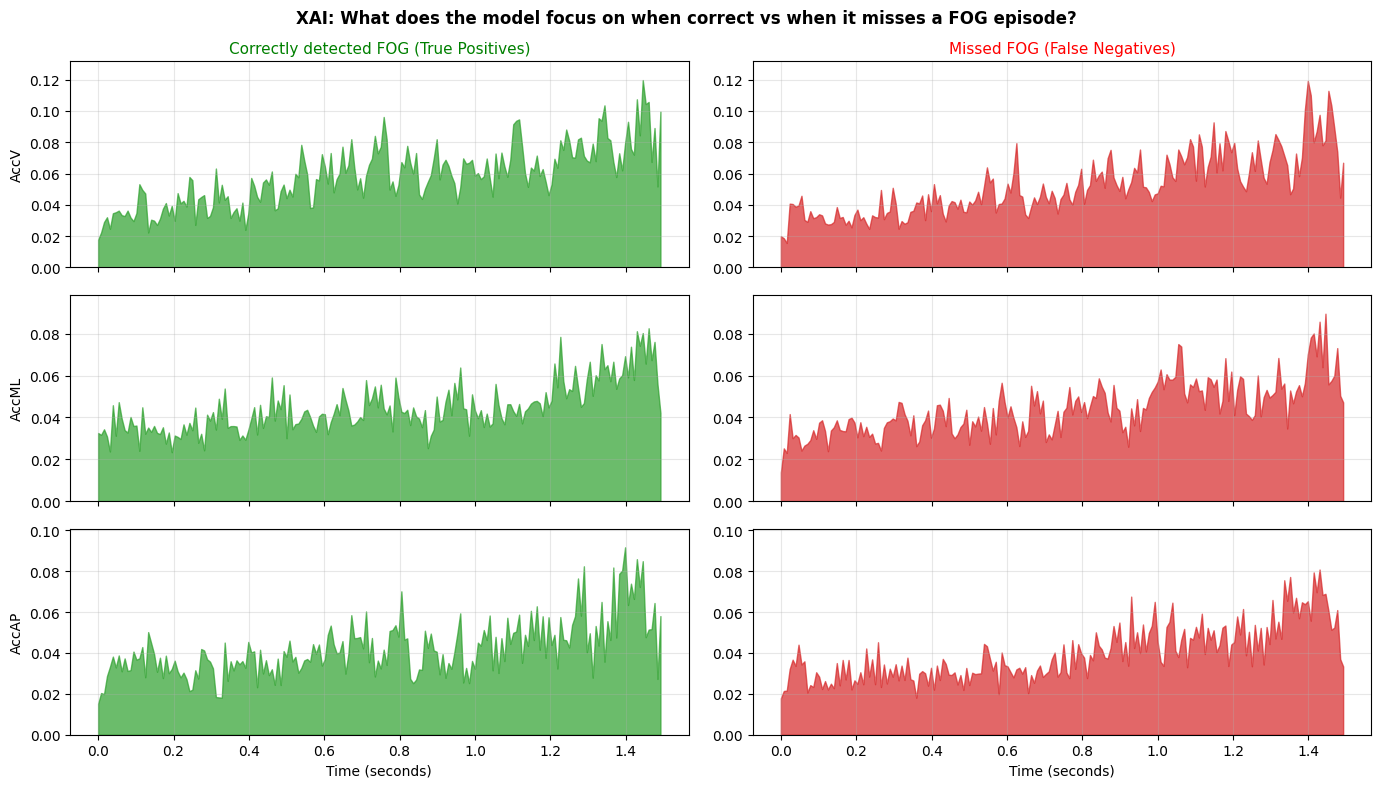

Saved: xai_tp_vs_fn.png

HOW TO READ THIS:
  If TP and FN have very DIFFERENT patterns:
    → The model learned a specific signal shape and misses FOG that looks different
  If TP and FN look SIMILAR:
    → The model struggles with confidence, not the signal shape


In [15]:
time_axis = np.arange(WINDOW_SIZE) / FS

if fn_attr is None:
    print('No false negatives found — your model is great! Showing TP attributions only.')
    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    for i, axis_name in enumerate(AXES):
        axes[i].fill_between(time_axis, tp_attr[:, i], color='#2ca02c', alpha=0.7, label='True Positives')
        axes[i].set_ylabel(axis_name)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
else:
    fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
    fig.suptitle(
        'XAI: What does the model focus on when correct vs when it misses a FOG episode?',
        fontsize=12, fontweight='bold'
    )
    axes[0][0].set_title('Correctly detected FOG (True Positives)', fontsize=11, color='green')
    axes[0][1].set_title('Missed FOG (False Negatives)', fontsize=11, color='red')

    for i, axis_name in enumerate(AXES):
        # Normalise both to same scale for fair comparison
        vmax = max(tp_attr[:, i].max(), fn_attr[:, i].max())

        axes[i][0].fill_between(time_axis, tp_attr[:, i], color='#2ca02c', alpha=0.7)
        axes[i][0].set_ylim(0, vmax * 1.1)
        axes[i][0].set_ylabel(axis_name, fontsize=10)
        axes[i][0].grid(True, alpha=0.3)

        axes[i][1].fill_between(time_axis, fn_attr[:, i], color='#d62728', alpha=0.7)
        axes[i][1].set_ylim(0, vmax * 1.1)
        axes[i][1].grid(True, alpha=0.3)

    for col in range(2):
        axes[-1][col].set_xlabel('Time (seconds)', fontsize=10)

plt.tight_layout()
plt.savefig('xai_tp_vs_fn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xai_tp_vs_fn.png')
print()
print('HOW TO READ THIS:')
print('  If TP and FN have very DIFFERENT patterns:')
print('    → The model learned a specific signal shape and misses FOG that looks different')
print('  If TP and FN look SIMILAR:')
print('    → The model struggles with confidence, not the signal shape')

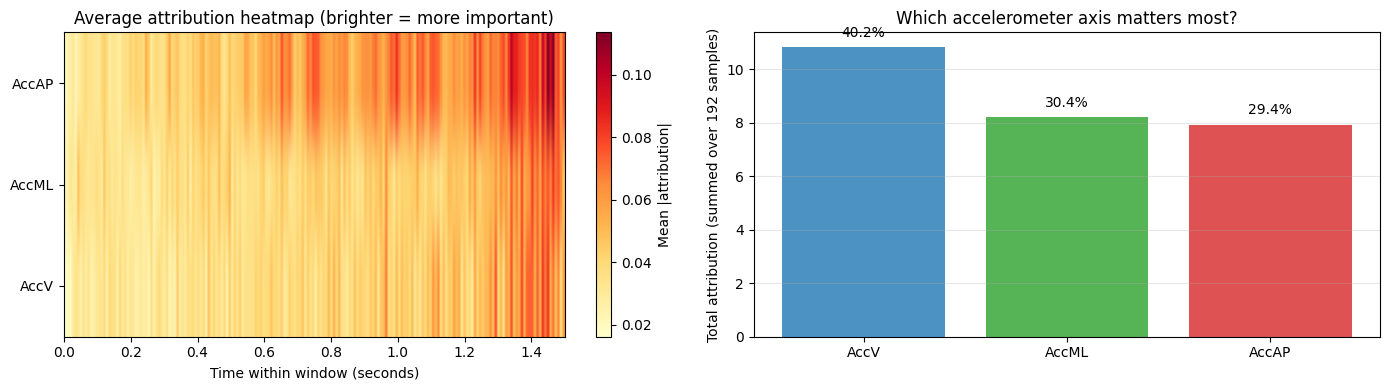

Saved: xai_heatmap_and_axis.png

HOW TO READ THIS:
  Bar chart tells you: which body axis (vertical / medio-lateral / antero-posterior)
  is most informative for the model when detecting FOG

  AccV   contribution: 40.2%
  AccML  contribution: 30.4%
  AccAP  contribution: 29.4%


In [16]:
# Use the mean_attr computed in cell 9
# mean_attr shape: (192, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: heatmap (time on x, axis on y)
im = axes[0].imshow(
    mean_attr.T,          # (3, 192) — rows=axes, cols=time
    aspect='auto',
    cmap='YlOrRd',
    extent=[0, WINDOW_SIZE/FS, -0.5, 2.5]
)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(AXES)
axes[0].set_xlabel('Time within window (seconds)')
axes[0].set_title('Average attribution heatmap (brighter = more important)')
plt.colorbar(im, ax=axes[0], label='Mean |attribution|')

# Right: per-axis total importance (bar chart)
axis_totals = mean_attr.sum(axis=0)   # sum over time for each axis
bars = axes[1].bar(AXES, axis_totals, color=['#1f77b4','#2ca02c','#d62728'], alpha=0.8)
axes[1].set_ylabel('Total attribution (summed over 192 samples)')
axes[1].set_title('Which accelerometer axis matters most?')
axes[1].grid(True, alpha=0.3, axis='y')

# Label bars with percentages
total = axis_totals.sum()
for bar, val in zip(bars, axis_totals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + total * 0.01,
        f'{val/total*100:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.savefig('xai_heatmap_and_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xai_heatmap_and_axis.png')
print()
print('HOW TO READ THIS:')
print('  Bar chart tells you: which body axis (vertical / medio-lateral / antero-posterior)')
print('  is most informative for the model when detecting FOG')
print()
print(f'  AccV   contribution: {axis_totals[0]/total*100:.1f}%')
print(f'  AccML  contribution: {axis_totals[1]/total*100:.1f}%')
print(f'  AccAP  contribution: {axis_totals[2]/total*100:.1f}%')